# Empirical $D_\ell$ histograms vs hmfast theory (1h only)

Compare binned tSZ power spectra from JXPaint painted maps
(`/rds/rds-lxu/JXPaint_validation/ps_from_painted_maps`) against hmfast
**1-halo theory only** — no 2-halo term (matches signal-only painted maps).

Gaussian mean and covariance from the 1-halo trispectrum (`cl_1h_masked`,
`trispectrum_1h_masked`).

Style matches `hmfast_histogram_scatter_masked_signal_only.png`:
LaTeX labels, 300 dpi, 25 pt fonts.

> **Environment:** `source /scratch/scratch-lxu/venv/cmbagent_env/bin/activate`, run from `notebook/`.
>
> **Theory (hmfast only):**
> - ParametricGNFW (`A_SZ`, `alpha_SZ`, `B=1.41`); physical $M_\odot$; `hm_consistency=False`
> - Masked: `q_cat=5` (undetected halos); full-sky: `q_cat=\infty` (scatter, all halos)
> - **No `cl_2h`** — empirical data are signal-only catalogue realizations
>
> **Masked plot uses the truncated profile** (`TruncatedParametricGNFWPressureProfile`,
> `notebook/truncated_gnfw.py`): JXPaint cuts each halo's projected profile at
> $\theta_{\max}=\min(\max(2\,\mathrm{FWHM},\,4\theta_{R200}),\,5^\circ)$. This is
> folded into `u_k` as $u_k \to u_k\,T(k,M,z)$ with $T=u_{2d}^{\mathrm{trunc}}/u_{2d}^{\mathrm{full}}$
> from a precomputed mcfit Hankel grid. hmfast source is untouched. This removes
> the $\sim 4\%$ low-$\ell$ deficit of the untruncated theory. Full-sky still uses
> the untruncated profile (a separate mid-$\ell$ excess there is under investigation).

In [1]:
import os
import sys
from pathlib import Path

# --- JAX device selection (must run before import jax; restart kernel after toggling) ---
USE_GPU = True
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
if USE_GPU:
    os.environ.setdefault("JAX_PLATFORMS", "cuda")
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
else:
    os.environ["JAX_PLATFORMS"] = "cpu"
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# hmfast from local checkout (no tszpower)
sys.path.insert(0, "/scratch/scratch-lxu/agent_dev/auto_research_agent/hmfast/src")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from scipy.stats import norm

jax.config.update("jax_enable_x64", True)
print("USE_GPU =", USE_GPU)
print("JAX devices:", jax.devices())

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "text.latex.preamble": (
        r"\usepackage[T1]{fontenc}\usepackage{type1cm}"
        r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}"
    ),
})

from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.mass_definition import MassDefinition
from hmfast.halos.profiles import ParametricGNFWPressureProfile
from hmfast.tracers import tSZTracer
from hmfast.tracers.tsz_completeness import (
    build_snr_grid,
    conditional_An_undetected,
    load_sigma_y0_curve,
)

%matplotlib inline

USE_GPU = True


JAX devices: [CudaDevice(id=0)]


In [2]:
PS_DIR = Path("/rds/rds-lxu/JXPaint_validation/ps_from_painted_maps")
OUT_DIR = Path("../notebook/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ELL_MIN = np.array(
    [9, 12, 16, 21, 27, 35, 46, 60, 78, 102, 133, 173, 224, 292, 380, 494, 642, 835],
    dtype=int,
)
ELL_MAX = np.array(
    [12, 16, 21, 27, 35, 46, 60, 78, 102, 133, 173, 224, 292, 380, 494, 642, 835, 1085],
    dtype=int,
)
ELL_EFF = np.array(
    [10.0, 13.5, 18.0, 23.5, 30.5, 40.0, 52.5, 68.5, 89.5, 117.0, 152.5,
     198.0, 257.5, 335.5, 436.5, 567.5, 738.0, 959.5],
)
N_BINS = len(ELL_EFF)

_L_MAX = int(np.max(ELL_MAX - ELL_MIN + 1))
_ELL_INT = ELL_MIN[:, None] + np.arange(_L_MAX)[None, :]
_ELL_MASK = (_ELL_INT <= ELL_MAX[:, None]).astype(np.float64)

# Mass grid: physical M_sun (hmfast convention)
M_MIN, M_MAX = 1e14, 1e16
Z_MIN, Z_MAX = 0.005, 3.0
N_GRID_MZ = 100

# Fiducial cosmology and ParametricGNFW profile
H0 = 67.66
omega_cdm = 0.1193
omega_b = 0.02242
ln10_10A_s = 2.9718
n_s = 0.9665
tau_reio = 0.0544
B_val = 1.41
A_SZ = -4.2373
alpha_SZ = 1.12
sigma_lnY = 0.173
q_cat = 5.0

In [3]:
def bin_to_18(ell_in: np.ndarray, Cl_in: np.ndarray) -> np.ndarray:
    """Top-hat binning used by hmfast benchmarks (integer ell weights)."""
    log_ell = np.log(np.asarray(ell_in, dtype=np.float64))
    Cl_q = np.interp(np.log(_ELL_INT.astype(float)), log_ell, np.asarray(Cl_in, dtype=np.float64))
    Dl_q = _ELL_INT * (_ELL_INT + 1.0) * Cl_q / (2.0 * np.pi) * 1e12
    num = np.sum(Dl_q * _ELL_MASK, axis=1)
    den = np.sum(_ELL_MASK, axis=1)
    return num / den


def bin_Dl_uniform(ell_full: np.ndarray, Dl_full: np.ndarray) -> np.ndarray:
    """Match compute_ps_from_painted_maps: uniform mean of D_ell in each bin."""
    ell_full = np.asarray(ell_full, dtype=np.float64)
    Dl_full = np.asarray(Dl_full, dtype=np.float64)
    Dl_bin = np.full(N_BINS, np.nan, dtype=np.float64)
    for ib in range(N_BINS):
        m = (ell_full >= ELL_MIN[ib]) & (ell_full <= ELL_MAX[ib])
        if np.any(m):
            Dl_bin[ib] = np.nanmean(Dl_full[m])
    return Dl_bin


def cl_to_Dl(ell: np.ndarray, cl: np.ndarray) -> np.ndarray:
    ell = np.asarray(ell, dtype=np.float64)
    cl = np.asarray(cl, dtype=np.float64)
    return ell * (ell + 1.0) * cl / (2.0 * np.pi) * 1e12


def theory_sigma_Dl(
    ell_int: np.ndarray,
    cl_int: np.ndarray,
    ell_tri: np.ndarray,
    trispec: np.ndarray,
    f_sky_eff: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Binned theory mean and Gaussian sigma (hmfast benchmark binning)."""
    Dl_theory = bin_to_18(ell_int, cl_int)

    ell_tri = np.asarray(ell_tri, dtype=np.float64)
    n_ell = len(ell_tri)
    Bop = np.zeros((N_BINS, n_ell), dtype=np.float64)
    for j in range(n_ell):
        e = np.zeros(n_ell, dtype=np.float64)
        e[j] = 1.0
        Bop[:, j] = bin_to_18(ell_tri, e)

    delta_ell = np.empty(n_ell)
    delta_ell[:-1] = np.diff(ell_tri)
    delta_ell[-1] = delta_ell[-2]

    C_tot = np.interp(ell_tri, ell_int, cl_int)
    diag_term = (4.0 * np.pi) * (C_tot ** 2) / (ell_tri + 0.5)
    M_G = np.diag(diag_term / (4.0 * np.pi * f_sky_eff * delta_ell))
    M_C = M_G + trispec / (4.0 * np.pi * f_sky_eff)
    M_D = Bop @ M_C @ Bop.T
    sigma_D = np.sqrt(np.clip(np.diag(M_D), 0.0, None))
    return Dl_theory, sigma_D

In [4]:
def load_empirical_ps(kind: str) -> tuple[np.ndarray, float | None, int]:
    """Load stacked D_ell realizations. kind: 'masked' or 'fullsky'."""
    key = {"masked": "Dl_masked", "fullsky": "Dl_fullsky"}[kind]
    txt_tmpl = {
        "masked": "Dl_binned_masked_signal_only_real{i}.txt",
        "fullsky": "Dl_binned_fullsky_signal_only_real{i}.txt",
    }[kind]
    npy_name = {
        "masked": "Dl_binned_masked_signal_only_all100.npy",
        "fullsky": "Dl_binned_fullsky_signal_only_all100.npy",
    }[kind]

    npz_files = sorted(
        PS_DIR.glob("ps_realization_*.npz"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )
    if npz_files:
        Dl = np.stack([np.load(p)[key] for p in npz_files])
        f_sky = np.array([float(np.load(p)["f_sky_eff"]) for p in npz_files])
        return Dl, float(np.mean(f_sky)), len(npz_files)

    npy_path = PS_DIR / npy_name
    if npy_path.is_file():
        Dl = np.load(npy_path)
        return Dl, None, Dl.shape[0]

    txt_files = sorted(
        PS_DIR.glob(txt_tmpl.replace("{i}", "*")),
        key=lambda p: int(p.stem.split("real")[-1]),
    )
    if not txt_files:
        raise FileNotFoundError(f"No PS files found in {PS_DIR} for {kind}")
    Dl = np.stack([np.loadtxt(p, comments="#")[:, 1] for p in txt_files])
    return Dl, None, Dl.shape[0]


Dl_masked, f_sky_mean, n_masked = load_empirical_ps("masked")
Dl_fullsky, _, n_fullsky = load_empirical_ps("fullsky")
print(f"Loaded {n_masked} masked and {n_fullsky} full-sky realizations, shape {Dl_masked.shape}")
if f_sky_mean is not None:
    print(f"Mean f_sky_eff (masked) = {f_sky_mean:.6f}")

Loaded 100 masked and 100 full-sky realizations, shape (100, 18)
Mean f_sky_eff (masked) = 0.941570


In [5]:
import time

def sync(x):
    return jax.block_until_ready(x)

print("Computing hmfast 1h-only theory on", jax.devices()[0], "...")
cosmo = Cosmology(emulator_set="lcdm:v1")
cosmo = cosmo.update(
    H0=H0, omega_cdm=omega_cdm, omega_b=omega_b,
    ln1e10A_s=ln10_10A_s, n_s=n_s, tau_reio=tau_reio,
)
hm = HaloModel(
    cosmology=cosmo,
    mass_definition=MassDefinition(500, "critical"),
    convert_masses=True,
    hm_consistency=False,  # required for pressure profiles (physical units)
)
prof = ParametricGNFWPressureProfile(A_SZ=A_SZ, alpha_SZ=alpha_SZ, B=B_val)
tsz = tSZTracer(profile=prof)

ell_int = jnp.geomspace(float(ELL_MIN[0]), float(ELL_MAX[-1]), 50)
ell_tri = jnp.geomspace(float(ELL_MIN[0]), float(ELL_MAX[-1]), 30)
m_grid = jnp.geomspace(M_MIN, M_MAX, N_GRID_MZ)  # physical M_sun
z_grid = jnp.geomspace(Z_MIN, Z_MAX, N_GRID_MZ)
coeff, _ = load_sigma_y0_curve()
coeff_j = jnp.asarray(coeff)

snr = build_snr_grid(
    hm, m_grid, z_grid, A_SZ=A_SZ, alpha_SZ=alpha_SZ, B=B_val, coeff=coeff_j,
)
# Masked: undetected halos (q_cat=5). Full-sky: q→∞ includes scatter for all halos.
mask_ps_ms = conditional_An_undetected(
    snr, sigma_lnY=sigma_lnY, q_cat=q_cat, n_power=2, n_grid=512, nsig=8.0,
)
mask_ps_fs = conditional_An_undetected(
    snr, sigma_lnY=sigma_lnY, q_cat=jnp.inf, n_power=2, n_grid=512, nsig=8.0,
)
mask_tri_ms = conditional_An_undetected(
    snr, sigma_lnY=sigma_lnY, q_cat=q_cat, n_power=4, n_grid=512, nsig=8.0,
)
mask_tri_fs = conditional_An_undetected(
    snr, sigma_lnY=sigma_lnY, q_cat=jnp.inf, n_power=4, n_grid=512, nsig=8.0,
)
sync(snr)

# --- 1-halo only: cl_1h_masked + trispectrum_1h_masked (no cl_2h) ---
t0 = time.perf_counter()
sync(hm.cl_1h_masked(tsz, None, ell_int, m_grid, z_grid, mask_ps_ms, k_damp=0.0))
sync(hm.cl_1h_masked(tsz, None, ell_int, m_grid, z_grid, mask_ps_fs, k_damp=0.0))
sync(hm.trispectrum_1h_masked(
    tsz, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_ms, k_damp=0.0,
))
sync(hm.trispectrum_1h_masked(
    tsz, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_fs, k_damp=0.0,
))
print(f"JIT warmup: {time.perf_counter() - t0:.2f} s")

t0 = time.perf_counter()
cl_fs_j = hm.cl_1h_masked(tsz, None, ell_int, m_grid, z_grid, mask_ps_fs, k_damp=0.0)
T_fs_j = hm.trispectrum_1h_masked(
    tsz, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_fs, k_damp=0.0,
)
cl_ms_j = hm.cl_1h_masked(tsz, None, ell_int, m_grid, z_grid, mask_ps_ms, k_damp=0.0)
T_ms_j = hm.trispectrum_1h_masked(
    tsz, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_ms, k_damp=0.0,
)
cl_fs_j, T_fs_j, cl_ms_j, T_ms_j = map(sync, (cl_fs_j, T_fs_j, cl_ms_j, T_ms_j))
print(f"hmfast theory on GPU: {time.perf_counter() - t0:.3f} s")

ell_int_np = np.asarray(ell_int)
ell_tri_np = np.asarray(ell_tri)
cl_fs = np.asarray(cl_fs_j)
cl_ms = np.asarray(cl_ms_j)
T_fs = np.asarray(T_fs_j)
T_ms = np.asarray(T_ms_j)

Dl_th_fs, sig_th_fs = theory_sigma_Dl(ell_int_np, cl_fs, ell_tri_np, T_fs, f_sky_eff=1.0)
f_sky_theory = f_sky_mean if f_sky_mean is not None else 0.9505089455619588
Dl_th_ms, sig_th_ms = theory_sigma_Dl(
    ell_int_np, cl_ms, ell_tri_np, T_ms, f_sky_eff=f_sky_theory,
)

print("Full-sky theory (first / last bin):")
for i in (0, 17):
    print(f"  ell={ELL_EFF[i]:6.1f}  D_th={Dl_th_fs[i]:.4e}  emp_mean={np.mean(Dl_fullsky[:, i]):.4e}")

Computing hmfast 1h-only theory on cuda:0 ...


JIT warmup: 5.65 s
hmfast theory on GPU: 0.029 s
Full-sky theory (first / last bin):
  ell=  10.0  D_th=2.5662e-03  emp_mean=2.4698e-03
  ell= 959.5  D_th=4.0652e-01  emp_mean=4.0731e-01


In [6]:

# --- Truncated profile: fold in JXPaint's theta_max cutoff (method 2) ---
# Subclass of ParametricGNFWPressureProfile that multiplies u_k by a
# precomputed T(k, M, z) = u2d_trunc / u2d_full. hmfast source untouched.
import time as _time
sys.path.insert(0, str(Path.cwd()))
from truncated_gnfw import TruncatedParametricGNFWPressureProfile

prof_tr = TruncatedParametricGNFWPressureProfile(
    A_SZ=A_SZ, alpha_SZ=alpha_SZ, B=B_val,
    fwhm_arcmin=10.0, cap_deg=5.0, n_mz=30, nperp=384, ns=512, nr=4096,
)
t0 = _time.perf_counter()
prof_tr.precompute(hm, M_MIN, M_MAX, Z_MIN, Z_MAX)
sync(jnp.zeros(()))  # ensure precompute ops flushed
print(f"precompute T(k,M,z): {_time.perf_counter() - t0:.2f} s")
tsz_tr = tSZTracer(profile=prof_tr)

# warmup truncated jit
sync(hm.cl_1h_masked(tsz_tr, None, ell_int, m_grid, z_grid, mask_ps_ms, k_damp=0.0))
sync(hm.trispectrum_1h_masked(
    tsz_tr, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_ms, k_damp=0.0,
))

t0 = _time.perf_counter()
cl_fs_tr = sync(hm.cl_1h_masked(tsz_tr, None, ell_int, m_grid, z_grid, mask_ps_fs, k_damp=0.0))
cl_ms_tr = sync(hm.cl_1h_masked(tsz_tr, None, ell_int, m_grid, z_grid, mask_ps_ms, k_damp=0.0))
T_fs_tr = sync(hm.trispectrum_1h_masked(
    tsz_tr, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_fs, k_damp=0.0,
))
T_ms_tr = sync(hm.trispectrum_1h_masked(
    tsz_tr, None, ell_tri, ell_tri, m_grid, z_grid, mask_tri_ms, k_damp=0.0,
))
print(f"truncated theory on GPU: {_time.perf_counter() - t0:.3f} s")

Dl_th_fs_tr, sig_th_fs_tr = theory_sigma_Dl(
    ell_int_np, np.asarray(cl_fs_tr), ell_tri_np, np.asarray(T_fs_tr), f_sky_eff=1.0,
)
Dl_th_ms_tr, sig_th_ms_tr = theory_sigma_Dl(
    ell_int_np, np.asarray(cl_ms_tr), ell_tri_np, np.asarray(T_ms_tr),
    f_sky_eff=f_sky_theory,
)

print("\nFull-sky:  emp_mean / parent_th / trunc_th  (ratio emp/parent, emp/trunc)")
emp_fs = np.mean(Dl_fullsky, axis=0)
for i in range(N_BINS):
    r_par = emp_fs[i] / Dl_th_fs[i]
    r_tr = emp_fs[i] / Dl_th_fs_tr[i]
    print(f"  ell={ELL_EFF[i]:7.1f}  emp={emp_fs[i]:.4e}  par={Dl_th_fs[i]:.4e} "
          f"tr={Dl_th_fs_tr[i]:.4e}  emp/par={r_par:.4f}  emp/tr={r_tr:.4f}")

print("\nMasked:  emp_mean / parent_th / trunc_th  (ratio emp/parent, emp/trunc)")
emp_ms = np.mean(Dl_masked, axis=0)
for i in range(N_BINS):
    r_par = emp_ms[i] / Dl_th_ms[i]
    r_tr = emp_ms[i] / Dl_th_ms_tr[i]
    print(f"  ell={ELL_EFF[i]:7.1f}  emp={emp_ms[i]:.4e}  par={Dl_th_ms[i]:.4e} "
          f"tr={Dl_th_ms_tr[i]:.4e}  emp/par={r_par:.4f}  emp/tr={r_tr:.4f}")


/scratch/scratch-lxu/agent_dev/auto_research_agent/mcfit/mcfit/mcfit.py:132: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


precompute T(k,M,z): 3.49 s


truncated theory on GPU: 0.033 s

Full-sky:  emp_mean / parent_th / trunc_th  (ratio emp/parent, emp/trunc)
  ell=   10.0  emp=2.4698e-03  par=2.5662e-03 tr=2.3234e-03  emp/par=0.9624  emp/tr=1.0630
  ell=   13.5  emp=4.2164e-03  par=4.1481e-03 tr=3.9239e-03  emp/par=1.0165  emp/tr=1.0745
  ell=   18.0  emp=6.6728e-03  par=6.4777e-03 tr=6.3998e-03  emp/par=1.0301  emp/tr=1.0427
  ell=   23.5  emp=1.0319e-02  par=9.6124e-03 tr=9.8143e-03  emp/par=1.0735  emp/tr=1.0514
  ell=   30.5  emp=1.5342e-02  par=1.3848e-02 tr=1.4336e-02  emp/par=1.1079  emp/tr=1.0701
  ell=   40.0  emp=2.1615e-02  par=1.9756e-02 tr=2.0203e-02  emp/par=1.0941  emp/tr=1.0699
  ell=   52.5  emp=2.9150e-02  par=2.7532e-02 tr=2.7397e-02  emp/par=1.0587  emp/tr=1.0640
  ell=   68.5  emp=3.9089e-02  par=3.7298e-02 tr=3.6754e-02  emp/par=1.0480  emp/tr=1.0635
  ell=   89.5  emp=5.2458e-02  par=4.9756e-02 tr=4.9717e-02  emp/par=1.0543  emp/tr=1.0551
  ell=  117.0  emp=6.8161e-02  par=6.5572e-02 tr=6.5615e-02  emp/par=1.03

In [7]:
def plot_histogram_grid(
    Dl_all: np.ndarray,
    Dl_theory: np.ndarray,
    sigma_theory: np.ndarray,
    title_suffix: str,
    out_stem: str,
) -> None:
    fig, axes = plt.subplots(3, 6, figsize=(20, 10), constrained_layout=True)
    axes = axes.flatten()

    for i in range(N_BINS):
        ax = axes[i]
        col = Dl_all[:, i]
        col = col[np.isfinite(col)]

        mu_th = Dl_theory[i]
        sig_th = sigma_theory[i]

        x_lo = min(np.min(col), mu_th - 4.0 * sig_th)
        x_hi = max(np.max(col), mu_th + 4.0 * sig_th)
        if x_hi <= x_lo:
            x_hi = x_lo + 1e-12

        edges = np.histogram_bin_edges(col, bins="fd", range=(x_lo, x_hi))
        if len(edges) < 2:
            edges = np.linspace(x_lo, x_hi, max(2, min(50, col.size // 2)))

        ax.hist(
            col, bins=edges, density=True, alpha=0.5, color="C0",
            histtype="stepfilled", label="Realizations" if i == 0 else None,
        )

        xg = np.linspace(x_lo, x_hi, 400)
        if np.isfinite(sig_th) and sig_th > 0:
            yg = norm.pdf(xg, loc=mu_th, scale=sig_th)
            ax.plot(xg, yg, "r-", lw=1.8, label="Theory Gaussian" if i == 0 else None)
            ax.axvline(mu_th, color="r", ls="--", lw=1.2, label="Theory mean" if i == 0 else None)

        ax.axvline(np.mean(col), color="k", ls="--", lw=1.2,
                   label="Empirical mean" if i == 0 else None)
        ax.set_title(rf"$\ell_{{\rm eff}}={ELL_EFF[i]:.1f}$")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=2, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((0, 0))
        ax.xaxis.set_major_formatter(fmt)

        if i >= 12:
            ax.set_xlabel(r"$D_\ell$")
        if i % 6 == 0:
            ax.set_ylabel("Probability Density")

    fig.canvas.draw()
    for ax in axes:
        ax.xaxis.get_offset_text().set_fontsize(18)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles, labels, loc="upper center", frameon=False, ncol=4,
            bbox_to_anchor=(0.5, 1.08),
        )

    fig.suptitle(title_suffix, y=1.14)
    png = OUT_DIR / f"{out_stem}.png"
    pdf = OUT_DIR / f"{out_stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {png}")

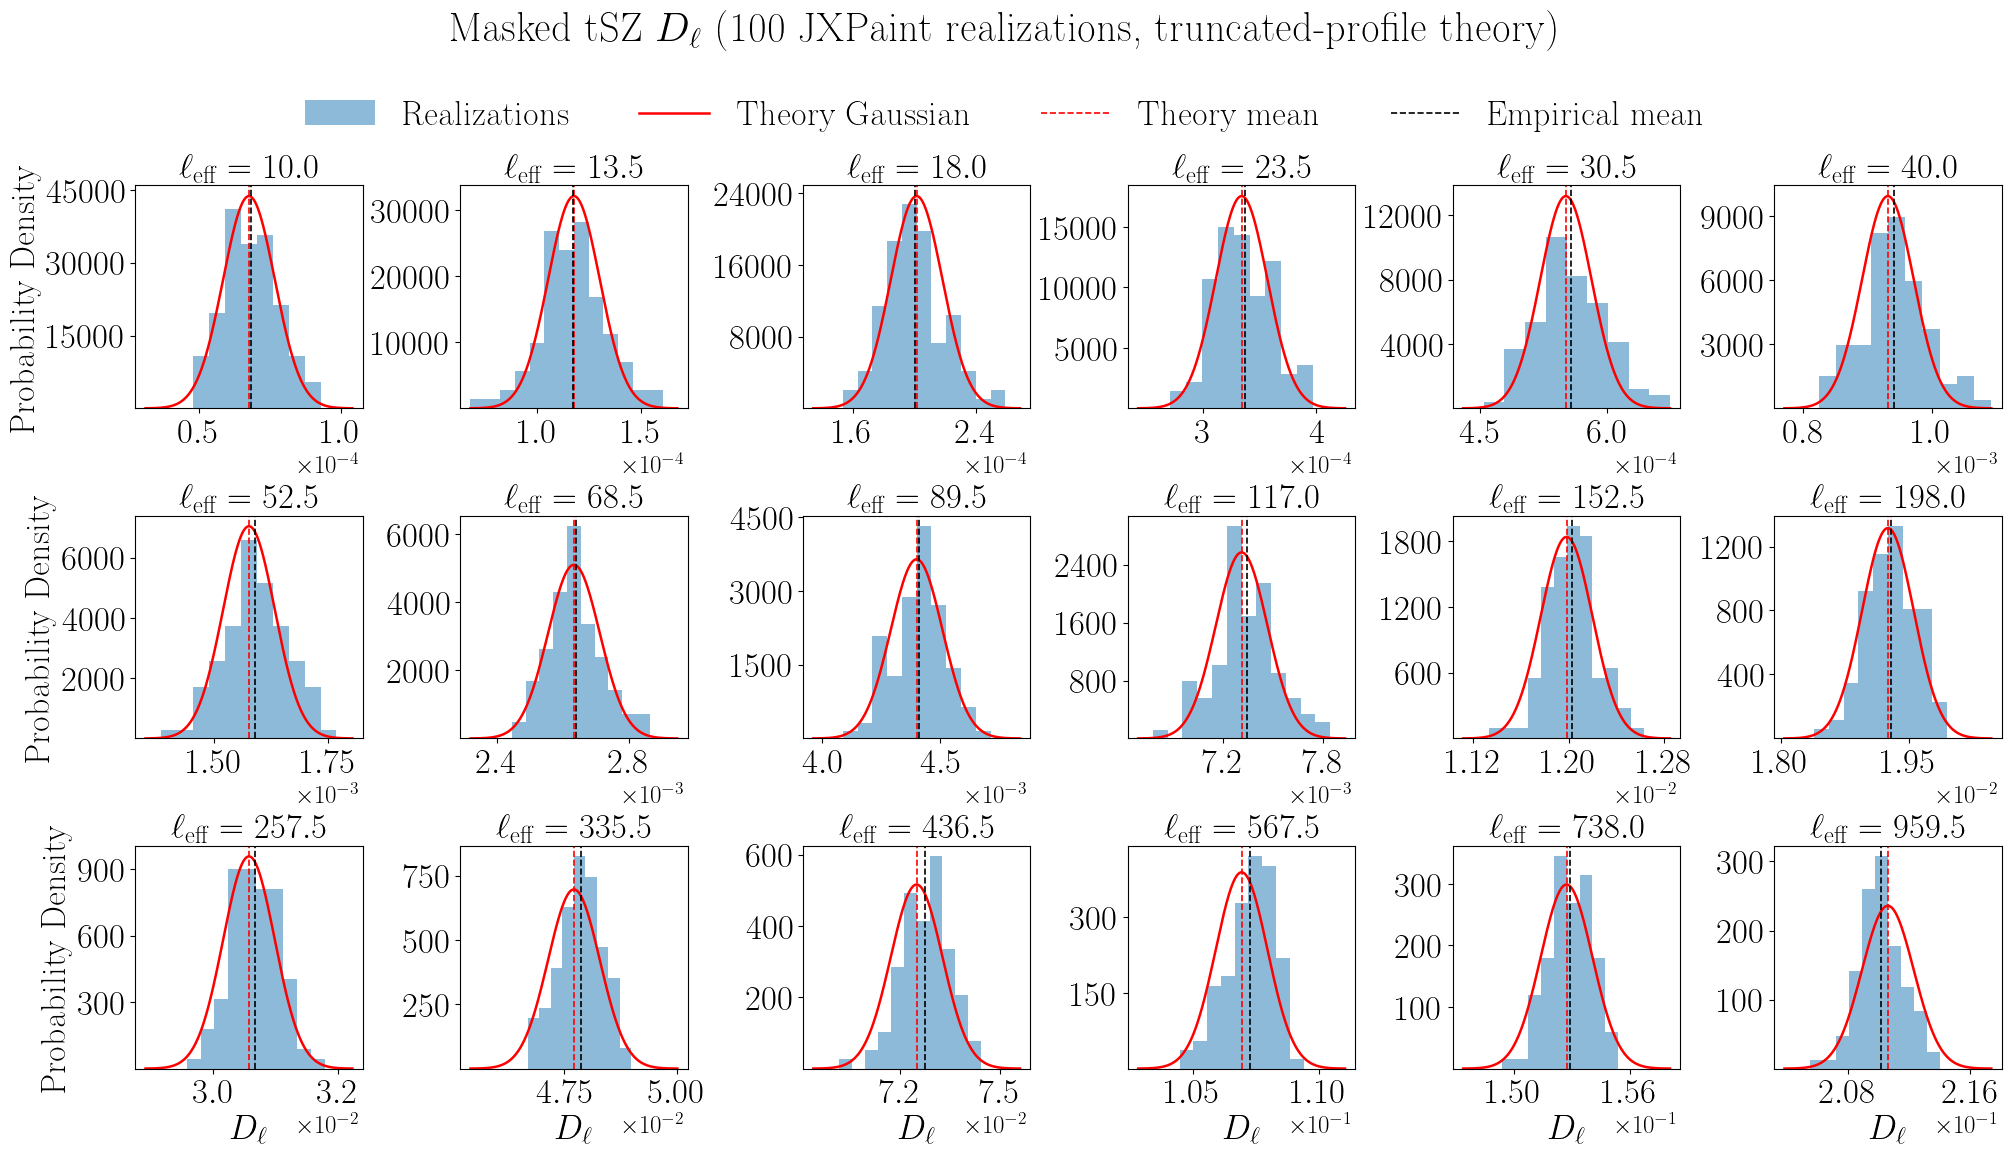

Saved ../notebook/figures/jxpaint_histogram_masked_signal_only.png


In [8]:
plot_histogram_grid(
    Dl_masked,
    Dl_th_ms_tr,
    sig_th_ms_tr,
    rf"Masked tSZ $D_\ell$ ({n_masked} JXPaint realizations, truncated-profile theory)",
    "jxpaint_histogram_masked_signal_only",
)

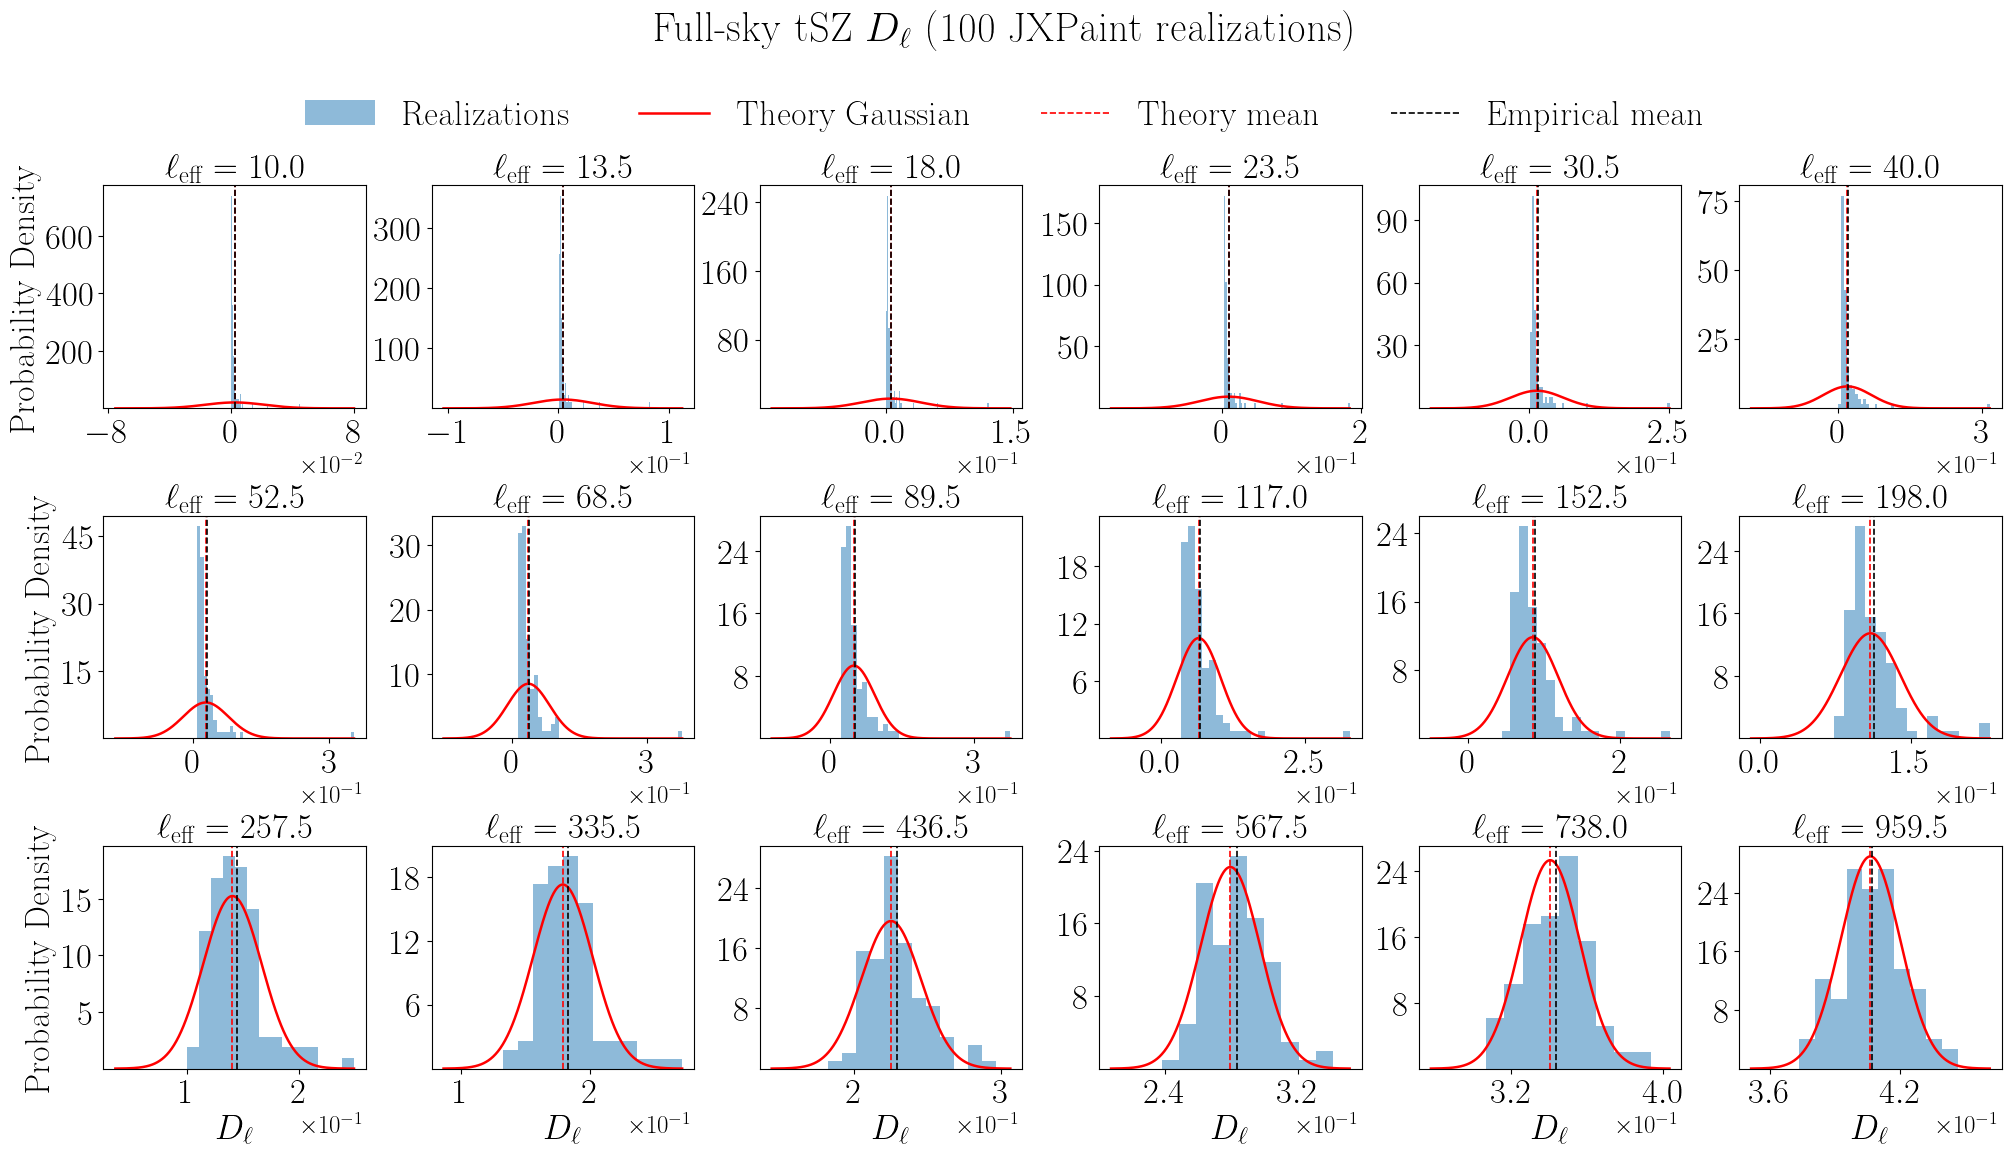

Saved ../notebook/figures/jxpaint_histogram_fullsky_signal_only.png


In [9]:
plot_histogram_grid(
    Dl_fullsky,
    Dl_th_fs,
    sig_th_fs,
    rf"Full-sky tSZ $D_\ell$ ({n_fullsky} JXPaint realizations)",
    "jxpaint_histogram_fullsky_signal_only",
)

In [10]:
# Per-bin diagnostics (masked, truncated theta_max theory)
Dl_mean = np.mean(Dl_masked, axis=0)
Dl_std = np.std(Dl_masked, axis=0, ddof=1)
print(f"{'ell_eff':>8}  {'mean/th':>8}  {'std/th':>8}  {'bias':>8}")
for i in range(N_BINS):
    ratio_mean = Dl_mean[i] / Dl_th_ms_tr[i]
    ratio_std = Dl_std[i] / sig_th_ms_tr[i]
    bias = (Dl_mean[i] - Dl_th_ms_tr[i]) / Dl_std[i]
    print(f"{ELL_EFF[i]:8.1f}  {ratio_mean:8.4f}  {ratio_std:8.4f}  {bias:+8.4f}")

 ell_eff   mean/th    std/th      bias
    10.0    1.0097    1.0070   +0.0712
    13.5    0.9974    1.2385   -0.0197
    18.0    0.9947    1.1569   -0.0547
    23.5    1.0079    1.1096   +0.1043
    30.5    1.0099    1.3808   +0.1311
    40.0    1.0099    1.2536   +0.1833
    52.5    1.0089    1.2080   +0.2048
    68.5    1.0025    1.0579   +0.0804
    89.5    1.0026    1.0115   +0.1047
   117.0    1.0041    1.1670   +0.1641
   152.5    1.0035    0.9703   +0.2006
   198.0    1.0020    0.9595   +0.1342
   257.5    1.0032    0.9205   +0.2554
   335.5    1.0031    0.8696   +0.2926
   436.5    1.0035    0.9069   +0.3644
   567.5    1.0033    0.9299   +0.3674
   738.0    1.0011    0.8455   +0.1501
   959.5    0.9979    0.8628   -0.3037
